## Forecaster: XGBoost
The linear weighted composite from `forecaster.ipynb` fails on forward labels: test AUC barely
clears 0.5 and sits below the equal-weight baseline. The relationship between indicators and
60-day-ahead drawdowns is nonlinear and interactions matter.

Feature engineering from `feature_engineering.ipynb` identified raw ranks + 21d/63d momentum
(48 features) as the winning feature set, with 60d/8% as the optimal label configuration.
This notebook applies those findings: XGBoost trained on the momentum feature set with
`TimeSeriesSplit(gap=LOOKAHEAD)`. Metrics: AUC and Brier score. Baseline: equal-weight stress score.

In [1]:
import os
from itertools import product
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier

N_JOBS = os.cpu_count()
print(f"using {N_JOBS} cores")

using 20 cores


### 1. Load data

In [2]:
try:
    df = pd.read_parquet("data/processed/stress_score.parquet")
    DOCS_PATH = Path("docs")
except FileNotFoundError:
    df = pd.read_parquet("../data/processed/stress_score.parquet")
    DOCS_PATH = Path("../docs")

df.index = pd.to_datetime(df.index)

INDICATOR_COLS = [
    "T10Y2Y",
    "T10Y3M",
    "T30Y10Y",
    "USALOLITOAASTSAM",
    "UMCSENT",
    "PERMIT",
    "NEWORDER",
    "ICSA",
    "DRCCLACBS",
    "BAMLH0A0HYM2",
    "XLK_XLV",
    "TLT",
    "HG=F",
    "CL=F",
    "EEM",
    "DX-Y.NYB",
]

df = df.dropna(subset=INDICATOR_COLS)
print(f"{len(df)} rows, {df.index[0].date()} to {df.index[-1].date()}")

5274 rows, 2005-04-27 to 2026-03-27


### 2. Forward drawdown labels

In [3]:
DRAWDOWN_THRESHOLD = 0.08
LOOKAHEAD = 60

spy = df["SPY"]

future_min = spy[::-1].rolling(window=LOOKAHEAD, min_periods=LOOKAHEAD).min()[::-1].shift(-1)
future_drop = future_min / spy - 1

labels_fwd = pd.Series(np.nan, index=spy.index)
valid = future_min.notna()
labels_fwd[valid] = (future_drop[valid] <= -DRAWDOWN_THRESHOLD).astype(float)
labels_fwd = labels_fwd.dropna().astype(int)

print(f"{len(labels_fwd)} rows; {labels_fwd.sum()} forward drawdown events ({labels_fwd.mean():.1%})")

5214 rows; 936 forward drawdown events (18.0%)


### 3. Feature engineering
Raw ranks + 21d/63d momentum per indicator (48 features). Identified as the winning feature
set in `feature_engineering.ipynb`: momentum is the only family that consistently lifts AUC
over baseline; every other addition tested degraded performance at this sample size.

In [4]:
MOM_WINDOWS = [21, 63]
ranks = df[INDICATOR_COLS]

mom_frames = [ranks]
for w in MOM_WINDOWS:
    mom_frames.append(
        (ranks - ranks.shift(w)).rename(columns={c: f"{c}_mom{w}" for c in INDICATOR_COLS})
    )

features = pd.concat(mom_frames, axis=1)
X_data = features.loc[labels_fwd.index].dropna()
y_data = labels_fwd.loc[X_data.index]

n_pos = y_data.sum()
n_neg = len(y_data) - n_pos
scale_pos_weight = n_neg / n_pos

print(f"{X_data.shape[1]} features, {len(X_data)} rows")
print(f"{n_pos} forward drawdown events ({y_data.mean():.1%})")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

48 features, 5151 rows
936 forward drawdown events (18.2%)
scale_pos_weight: 4.50


### 4. Baseline (equal-weight stress score)
The baseline uses the equal-weight average of raw ranks, aligned to the momentum feature
index (which drops 63 warmup rows). This keeps the comparison honest: baseline and model
are evaluated on the same rows.

In [5]:
N = len(INDICATOR_COLS)
equal_score = ranks.loc[X_data.index].sum(axis=1) / N

tscv_base = TimeSeriesSplit(n_splits=5, gap=LOOKAHEAD)
baseline_aucs, baseline_briers = [], []

for _, test_idx in tscv_base.split(X_data):
    y_test = y_data.iloc[test_idx]
    eq_test = equal_score.iloc[test_idx]
    if y_test.nunique() < 2:
        continue
    baseline_aucs.append(roc_auc_score(y_test, eq_test))
    baseline_briers.append(brier_score_loss(y_test, eq_test))

print(f"equal-weight baseline  AUC: {np.mean(baseline_aucs):.4f}  Brier: {np.mean(baseline_briers):.4f}")

equal-weight baseline  AUC: 0.6502  Brier: 0.2292


### 5. XGBoost CV (base params)
Shallow trees (`max_depth=3`) and a low learning rate reduce overfitting on a dataset where
drawdown events are sparse and the signal is noisy. `scale_pos_weight` corrects for class imbalance.

In [6]:
def run_xgb_cv(params, X, y, n_splits=5, gap=LOOKAHEAD):
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    folds = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if y_train.nunique() < 2 or y_test.nunique() < 2:
            continue

        model = XGBClassifier(**params, eval_metric="logloss", verbosity=0)
        model.fit(X_train, y_train)

        train_proba = model.predict_proba(X_train)[:, 1]
        test_proba = model.predict_proba(X_test)[:, 1]

        folds.append(
            {
                "fold": fold + 1,
                "test_start": X.index[test_idx[0]].date(),
                "test_end": X.index[test_idx[-1]].date(),
                "train_auc": roc_auc_score(y_train, train_proba),
                "auc": roc_auc_score(y_test, test_proba),
                "brier": brier_score_loss(y_test, test_proba),
            }
        )

    return folds


BASE_PARAMS = {
    "n_estimators": 200,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42,
    "tree_method": "hist",
}

base_folds = run_xgb_cv(BASE_PARAMS, X_data, y_data)

print("XGBoost base CV:")
for f in base_folds:
    print(f"  fold {f['fold']} ({f['test_start']} to {f['test_end']}):  train AUC={f['train_auc']:.4f}  test AUC={f['auc']:.4f}  Brier={f['brier']:.4f}")
print()
print(f"mean train AUC: {np.mean([f['train_auc'] for f in base_folds]):.4f}")
print(f"mean test AUC:  {np.mean([f['auc'] for f in base_folds]):.4f}")
print(f"mean Brier:     {np.mean([f['brier'] for f in base_folds]):.4f}")

XGBoost base CV:
  fold 1 (2008-12-17 to 2012-05-14):  train AUC=1.0000  test AUC=0.4793  Brier=0.3084
  fold 2 (2012-05-15 to 2015-10-12):  train AUC=0.9995  test AUC=0.7378  Brier=0.1455
  fold 3 (2015-10-13 to 2019-03-11):  train AUC=0.9994  test AUC=0.7279  Brier=0.1283
  fold 4 (2019-03-12 to 2022-08-04):  train AUC=0.9989  test AUC=0.5418  Brier=0.2305
  fold 5 (2022-08-05 to 2025-12-30):  train AUC=0.9979  test AUC=0.5383  Brier=0.1435

mean train AUC: 0.9992
mean test AUC:  0.6050
mean Brier:     0.1912


### 6. Hyperparameter sweep (refined)
Broad sweep identified depth=3 and low learning rate as the winning region. This sweep fixes
depth=3 and refines `n_estimators` and `learning_rate` with denser coverage around that region
(15 combinations). Selection criterion: `mean_auc - std_auc` to penalize variance.

In [7]:
# Narrow grid around the winning region from the broad sweep (n_estimators=100, depth=3, lr=0.01).
# depth=3 is fixed; lr and n_estimators are refined with denser coverage.
PARAM_GRID = {
    "n_estimators": [75, 100, 150, 200, 300],
    "max_depth": [3],
    "learning_rate": [0.005, 0.01, 0.02],
}

param_combos = [
    {"n_estimators": n, "max_depth": d, "learning_rate": lr}
    for n, d, lr in product(PARAM_GRID["n_estimators"], PARAM_GRID["max_depth"], PARAM_GRID["learning_rate"])
]

print(f"{len(param_combos)} combinations")


def _sweep_job(combo, X, y):
    params = {
        **combo,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "scale_pos_weight": n_neg / n_pos,
        "random_state": 42,
        "tree_method": "hist",
    }
    folds = run_xgb_cv(params, X, y)
    return {
        **combo,
        "mean_train_auc": np.mean([f["train_auc"] for f in folds]),
        "mean_auc": np.mean([f["auc"] for f in folds]),
        "mean_brier": np.mean([f["brier"] for f in folds]),
        "std_auc": np.std([f["auc"] for f in folds]),
    }


sweep_raw = Parallel(n_jobs=N_JOBS)(delayed(_sweep_job)(c, X_data, y_data) for c in param_combos)
sweep_results = sorted(sweep_raw, key=lambda r: r["mean_auc"], reverse=True)
print("sweep complete")

15 combinations
sweep complete


In [8]:
print(f"{'n_est':>6}  {'depth':>5}  {'lr':>5}  {'AUC':>7}  {'std':>6}  {'Brier':>7}")
for r in sweep_results[:15]:
    print(
        f"{r['n_estimators']:>6}  {r['max_depth']:>5}  {r['learning_rate']:>5}  "
        f"{r['mean_auc']:>7.4f}  {r['std_auc']:>6.4f}  {r['mean_brier']:>7.4f}"
    )

 n_est  depth     lr      AUC     std    Brier
   150      3   0.02   0.6181  0.1489   0.2092
   200      3   0.02   0.6167  0.1410   0.2069
   300      3   0.02   0.6152  0.1387   0.2026
   300      3   0.01   0.6100  0.1504   0.2187
   200      3   0.01   0.5969  0.1531   0.2214
   100      3   0.02   0.5958  0.1621   0.2165
   150      3   0.01   0.5884  0.1475   0.2209
    75      3   0.02   0.5881  0.1487   0.2177
   300      3  0.005   0.5866  0.1411   0.2178
   100      3   0.01   0.5833  0.1455   0.2223
   200      3  0.005   0.5805  0.1250   0.2197
    75      3   0.01   0.5793  0.1264   0.2281
   150      3  0.005   0.5747  0.1221   0.2250
   100      3  0.005   0.5637  0.1252   0.2350
    75      3  0.005   0.5618  0.1071   0.2430


In [9]:
# penalize variance: prefer stable AUC over lucky single-fold peaks
best = max(sweep_results, key=lambda r: r["mean_auc"] - r["std_auc"])
print(
    f"best: n_estimators={best['n_estimators']}  max_depth={best['max_depth']}  "
    f"learning_rate={best['learning_rate']}\n"
    f"      AUC={best['mean_auc']:.4f} +/- {best['std_auc']:.4f}  Brier={best['mean_brier']:.4f}"
)

best: n_estimators=300  max_depth=3  learning_rate=0.02
      AUC=0.6152 +/- 0.1387  Brier=0.2026


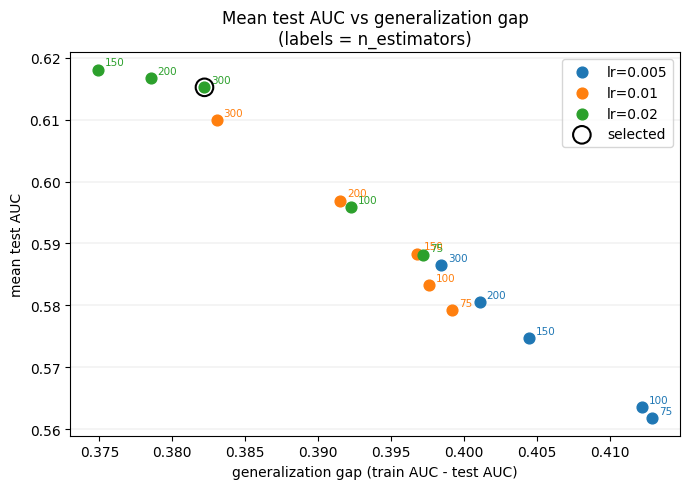

In [10]:
best_idx = max(range(len(sweep_results)), key=lambda i: sweep_results[i]["mean_auc"] - sweep_results[i]["std_auc"])

gaps = [r["mean_train_auc"] - r["mean_auc"] for r in sweep_results]
test_aucs = [r["mean_auc"] for r in sweep_results]
lrs = [r["learning_rate"] for r in sweep_results]
n_ests = [r["n_estimators"] for r in sweep_results]

lr_values = sorted(set(lrs))
colors = {lr: c for lr, c in zip(lr_values, ["#1f77b4", "#ff7f0e", "#2ca02c"])}

fig, ax = plt.subplots(figsize=(7, 5))

for lr in lr_values:
    idx = [i for i, r in enumerate(sweep_results) if r["learning_rate"] == lr]
    ax.scatter(
        [gaps[i] for i in idx],
        [test_aucs[i] for i in idx],
        color=colors[lr],
        label=f"lr={lr}",
        s=60,
        zorder=3,
    )
    for i in idx:
        ax.annotate(
            str(n_ests[i]),
            (gaps[i], test_aucs[i]),
            textcoords="offset points",
            xytext=(5, 3),
            fontsize=7.5,
            color=colors[lr],
        )

ax.scatter(
    gaps[best_idx],
    test_aucs[best_idx],
    s=160,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    zorder=4,
    label="selected",
)

ax.set_xlabel("generalization gap (train AUC - test AUC)")
ax.set_ylabel("mean test AUC")
ax.set_title("Mean test AUC vs generalization gap\n(labels = n_estimators)")
ax.legend()
ax.yaxis.grid(True, linewidth=0.3, color="grey", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 7. Final CV with best params

In [11]:
BEST_PARAMS = {
    "n_estimators": best["n_estimators"],
    "max_depth": best["max_depth"],
    "learning_rate": best["learning_rate"],
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42,
    "tree_method": "hist",
}

best_folds = run_xgb_cv(BEST_PARAMS, X_data, y_data)

print("final CV (best params):")
for f in best_folds:
    print(f"  fold {f['fold']} ({f['test_start']} to {f['test_end']}):  AUC={f['auc']:.4f}  Brier={f['brier']:.4f}")
print()
print(f"baseline           AUC: {np.mean(baseline_aucs):.4f}  Brier: {np.mean(baseline_briers):.4f}")
print(f"XGBoost (tuned)    AUC: {np.mean([f['auc'] for f in best_folds]):.4f}  Brier: {np.mean([f['brier'] for f in best_folds]):.4f}")

final CV (best params):
  fold 1 (2008-12-17 to 2012-05-14):  AUC=0.4716  Brier=0.3282
  fold 2 (2012-05-15 to 2015-10-12):  AUC=0.8213  Brier=0.1763
  fold 3 (2015-10-13 to 2019-03-11):  AUC=0.7063  Brier=0.1262
  fold 4 (2019-03-12 to 2022-08-04):  AUC=0.5262  Brier=0.2281
  fold 5 (2022-08-05 to 2025-12-30):  AUC=0.5257  Brier=0.1776

baseline           AUC: 0.6502  Brier: 0.2292
XGBoost (tuned)    AUC: 0.6102  Brier: 0.2073


### 8. Feature importance

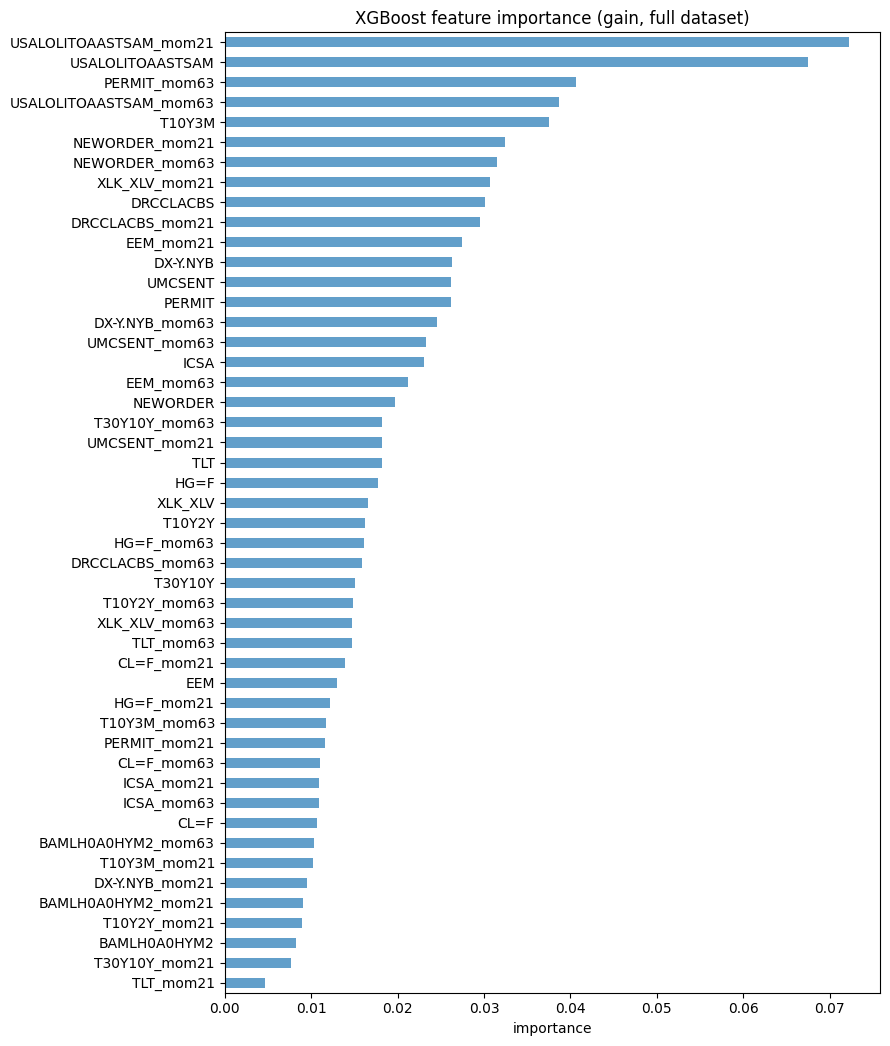

top 10:
USALOLITOAASTSAM_mom21    0.072202
USALOLITOAASTSAM          0.067428
PERMIT_mom63              0.040627
USALOLITOAASTSAM_mom63    0.038700
T10Y3M                    0.037526
NEWORDER_mom21            0.032474
NEWORDER_mom63            0.031564
XLK_XLV_mom21             0.030712
DRCCLACBS                 0.030067
DRCCLACBS_mom21           0.029537


In [12]:
# fit on full dataset for feature importance - in-sample only
final_model = XGBClassifier(**BEST_PARAMS, eval_metric="logloss", verbosity=0)
final_model.fit(X_data, y_data)

importances = pd.Series(final_model.feature_importances_, index=X_data.columns)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, max(4, len(importances) * 0.22)))
importances.plot.barh(ax=ax, color="#1f77b4", alpha=0.7)
ax.invert_yaxis()
ax.set_title("XGBoost feature importance (gain, full dataset)")
ax.set_xlabel("importance")
plt.tight_layout()
fig.savefig(DOCS_PATH / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("top 10:")
print(importances.head(10).to_string())

### 9. Probability visualization

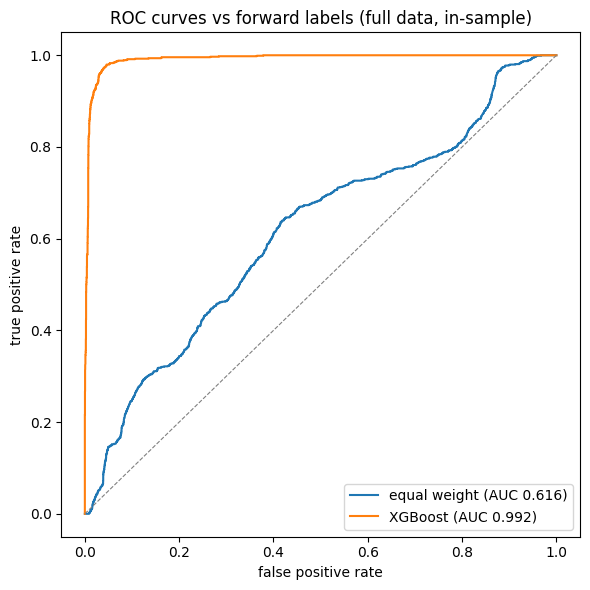

In [13]:
drawdown_prob = pd.Series(final_model.predict_proba(X_data)[:, 1], index=X_data.index)

fig, ax = plt.subplots(figsize=(6, 6))

for score, label, color in [
    (equal_score, f"equal weight (AUC {roc_auc_score(y_data, equal_score):.3f})", "#aec7e8"),
    (drawdown_prob, f"XGBoost (AUC {roc_auc_score(y_data, drawdown_prob):.3f})", "#d62728"),
]:
    fpr, tpr, _ = roc_curve(y_data, score)
    ax.plot(fpr, tpr, label=label)

ax.plot([0, 1], [0, 1], color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curves vs forward labels (full data, in-sample)")
ax.legend()
plt.tight_layout()
fig.savefig(DOCS_PATH / "roc_forecaster.png", dpi=150, bbox_inches="tight")
plt.show()

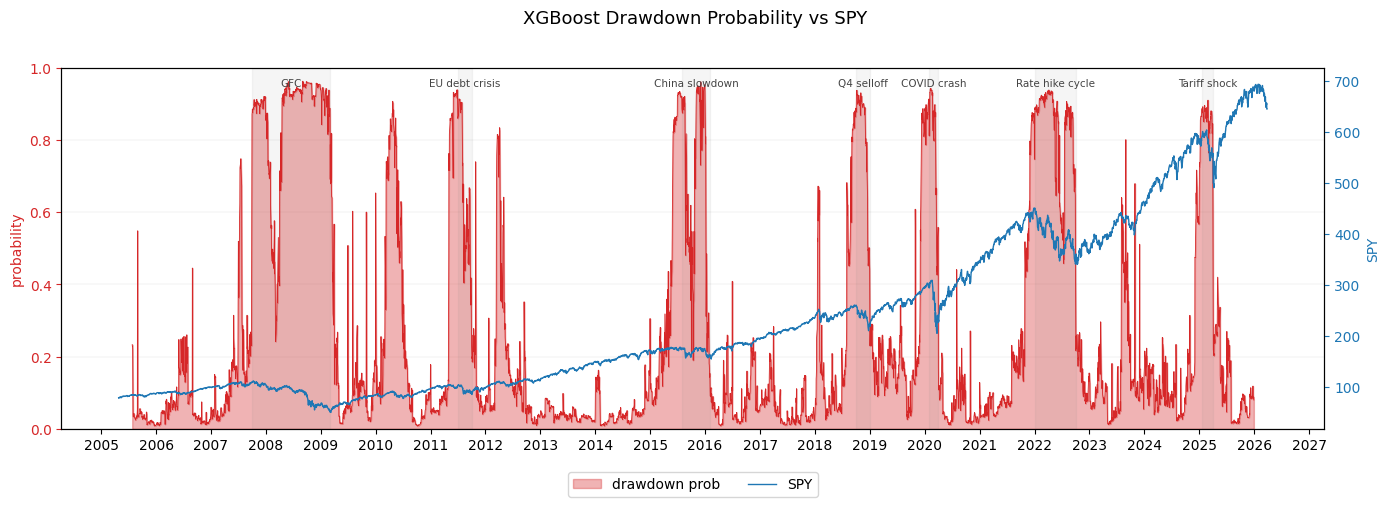

In [14]:
STRESS_PERIODS = [
    ("2007-10-01", "2009-03-01", "GFC"),
    ("2011-07-01", "2011-10-01", "EU debt crisis"),
    ("2015-08-01", "2016-02-01", "China slowdown"),
    ("2018-10-01", "2018-12-31", "Q4 selloff"),
    ("2020-02-01", "2020-04-01", "COVID crash"),
    ("2022-01-01", "2022-10-01", "Rate hike cycle"),
    ("2025-01-20", "2025-04-01", "Tariff shock"),
]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.fill_between(drawdown_prob.index, drawdown_prob, alpha=0.35, color="#d62728", label="drawdown prob")
ax1.plot(drawdown_prob.index, drawdown_prob, color="#d62728", linewidth=0.6)
ax2.plot(df.index, df["SPY"], color="#1f77b4", linewidth=1.0, label="SPY")

for start, end, label in STRESS_PERIODS:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color="grey")
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax1.text(
        mid, 0.97, label, ha="center", va="top", fontsize=7.5,
        color="#444444", transform=ax1.get_xaxis_transform(),
    )

ax1.set_ylabel("probability", color="#d62728")
ax2.set_ylabel("SPY", color="#1f77b4")
ax1.set_ylim(0, 1)
ax1.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax1.yaxis.grid(True, linewidth=0.3, color="grey", alpha=0.25)
ax1.set_axisbelow(True)
ax2.yaxis.grid(False)
ax1.tick_params(axis="y", colors="#d62728")
ax2.tick_params(axis="y", colors="#1f77b4")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator())

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)

fig.suptitle("XGBoost Drawdown Probability vs SPY", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(DOCS_PATH / "drawdown_prob_vs_spy.png", dpi=150, bbox_inches="tight")
plt.show()

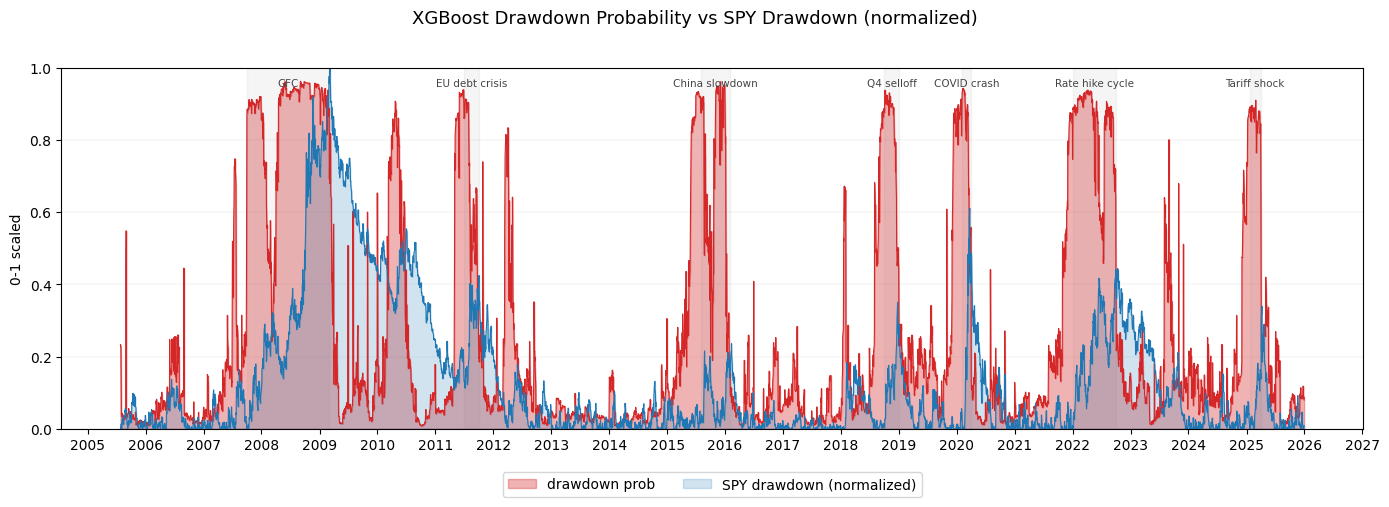

In [15]:
spy_dd = -(spy / spy.expanding().max() - 1)
spy_dd_norm = (spy_dd - spy_dd.min()) / (spy_dd.max() - spy_dd.min())
spy_dd_norm = spy_dd_norm.loc[X_data.index]

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(drawdown_prob.index, drawdown_prob, alpha=0.35, color="#d62728", label="drawdown prob")
ax.plot(drawdown_prob.index, drawdown_prob, color="#d62728", linewidth=0.8)

ax.fill_between(spy_dd_norm.index, spy_dd_norm, alpha=0.20, color="#1f77b4", label="SPY drawdown (normalized)")
ax.plot(spy_dd_norm.index, spy_dd_norm, color="#1f77b4", linewidth=0.8)

for start, end, label in STRESS_PERIODS:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color="grey")
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(
        mid, 0.97, label, ha="center", va="top", fontsize=7.5,
        color="#444444", transform=ax.get_xaxis_transform(),
    )

ax.set_ylim(0, 1)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylabel("0-1 scaled")
ax.yaxis.grid(True, linewidth=0.3, color="grey", alpha=0.25)
ax.set_axisbelow(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
fig.suptitle("XGBoost Drawdown Probability vs SPY Drawdown (normalized)", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(DOCS_PATH / "drawdown_prob_vs_spy_drawdown.png", dpi=150, bbox_inches="tight")
plt.show()

### 10. Per-fold diagnosis

Regularization barely moved the gap. Before tuning further, check whether the gap is uniform
across folds or concentrated in later ones. Uniform gap = capacity/memorization problem.
Gap growing in later folds = regime shift â€” the model learned patterns from earlier macro
regimes (GFC, COVID) that do not transfer to more recent periods. Regularization cannot fix
regime shift.

In [16]:
print(f"{'fold':>4}  {'test period':>25}  {'train_AUC':>9}  {'test_AUC':>8}  {'gap':>6}")
print("-" * 62)
for f in best_folds:
    gap = f["train_auc"] - f["auc"]
    print(
        f"{f['fold']:>4}  {str(f['test_start']):>12} to {str(f['test_end']):<12}"
        f"  {f['train_auc']:>9.4f}  {f['auc']:>8.4f}  {gap:>6.4f}"
    )
mean_gap = sum(f["train_auc"] - f["auc"] for f in best_folds) / len(best_folds)
print("-" * 62)
print(f"{'mean':>4}  {'':>25}  {sum(f['train_auc'] for f in best_folds)/len(best_folds):>9.4f}"
      f"  {sum(f['auc'] for f in best_folds)/len(best_folds):>8.4f}  {mean_gap:>6.4f}")

fold                test period  train_AUC  test_AUC     gap
--------------------------------------------------------------
   1    2008-12-17 to 2012-05-14       0.9999    0.4716  0.5283
   2    2012-05-15 to 2015-10-12       0.9979    0.8213  0.1766
   3    2015-10-13 to 2019-03-11       0.9979    0.7063  0.2916
   4    2019-03-12 to 2022-08-04       0.9970    0.5262  0.4708
   5    2022-08-05 to 2025-12-30       0.9948    0.5257  0.4691
--------------------------------------------------------------
mean                                0.9975    0.6102  0.3873


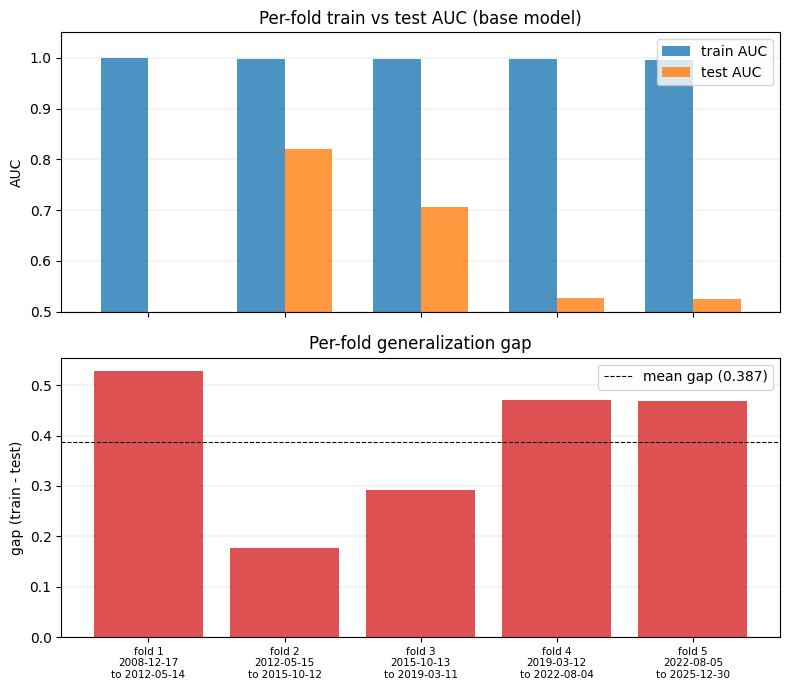

In [17]:
folds_n = [f["fold"] for f in best_folds]
train_aucs = [f["train_auc"] for f in best_folds]
test_aucs  = [f["auc"] for f in best_folds]
gaps       = [f["train_auc"] - f["auc"] for f in best_folds]
labels     = [f"{f['test_start'].year}" for f in best_folds]

x = range(len(best_folds))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

ax1.bar([i - width/2 for i in x], train_aucs, width, label="train AUC", color="#1f77b4", alpha=0.8)
ax1.bar([i + width/2 for i in x], test_aucs,  width, label="test AUC",  color="#ff7f0e", alpha=0.8)
ax1.set_ylabel("AUC")
ax1.set_ylim(0.5, 1.05)
ax1.legend()
ax1.yaxis.grid(True, linewidth=0.3, color="grey", alpha=0.4)
ax1.set_axisbelow(True)
ax1.set_title("Per-fold train vs test AUC (base model)")

ax2.bar(x, gaps, color="#d62728", alpha=0.8)
ax2.axhline(sum(gaps) / len(gaps), color="black", linestyle="--", linewidth=0.8, label=f"mean gap ({sum(gaps)/len(gaps):.3f})")
ax2.set_ylabel("gap (train - test)")
ax2.set_xticks(list(x))
ax2.set_xticklabels([f"fold {f['fold']}\n{f['test_start']}\nto {f['test_end']}" for f in best_folds], fontsize=7.5)
ax2.legend()
ax2.yaxis.grid(True, linewidth=0.3, color="grey", alpha=0.4)
ax2.set_axisbelow(True)
ax2.set_title("Per-fold generalization gap")

plt.tight_layout()
plt.show()

### 11. Recency weighting

Fold 5 (2022-2026) drives the gap: test AUC 0.4964, below random chance. The model learned
stress patterns from the GFC and COVID and applies them to a structurally different regime
(post-rate-hike recovery, AI bull market, tariff shock). Regularization cannot fix a
distribution shift.

Recency weighting assigns exponentially decaying sample weights so recent training examples
contribute more to the loss. Weights are computed relative to the end of each training fold,
so the most recent sample in that fold always gets weight 1.0. The half-life controls how fast
older samples decay: 252 days means a sample from one year ago gets weight 0.5.

The sweep uses the best XGBoost params from section 6. Half-life None is the unweighted baseline.

In [18]:
def compute_sample_weights(index, half_life):
    days_back = (index[-1] - index).days
    return np.exp(-np.log(2) / half_life * days_back)


def run_xgb_cv_weighted(params, X, y, half_life=None, n_splits=5, gap=LOOKAHEAD):
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    folds = []
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        if y_train.nunique() < 2 or y_test.nunique() < 2:
            continue
        sw = compute_sample_weights(X_train.index, half_life) if half_life else None
        model = XGBClassifier(**params, eval_metric="logloss", verbosity=0)
        model.fit(X_train, y_train, sample_weight=sw)
        train_proba = model.predict_proba(X_train)[:, 1]
        test_proba  = model.predict_proba(X_test)[:, 1]
        folds.append({
            "fold": fold + 1,
            "test_start": X.index[test_idx[0]].date(),
            "test_end":   X.index[test_idx[-1]].date(),
            "train_auc":  roc_auc_score(y_train, train_proba),
            "auc":        roc_auc_score(y_test,  test_proba),
            "brier":      brier_score_loss(y_test, test_proba),
        })
    return folds


HALF_LIFE_VALUES = [63, 126, 252, 504, None]

hl_results = {}
for hl in HALF_LIFE_VALUES:
    hl_results[hl] = run_xgb_cv_weighted(BEST_PARAMS, X_data, y_data, half_life=hl)
    label = f"hl={hl}" if hl else "none"
    mean_auc = np.mean([f["auc"] for f in hl_results[hl]])
    fold5_auc = next(f["auc"] for f in hl_results[hl] if f["fold"] == 5)
    print(f"{label:>8}  mean_AUC={mean_auc:.4f}  fold5_AUC={fold5_auc:.4f}")

   hl=63  mean_AUC=0.5170  fold5_AUC=0.6229
  hl=126  mean_AUC=0.6099  fold5_AUC=0.5362
  hl=252  mean_AUC=0.6094  fold5_AUC=0.5188
  hl=504  mean_AUC=0.6576  fold5_AUC=0.5688
    none  mean_AUC=0.6102  fold5_AUC=0.5257


In [19]:
# Per-fold breakdown for each half-life
header = f"{'hl':>6}  {'fold':>4}  {'test period':>25}  {'train_AUC':>9}  {'test_AUC':>8}  {'gap':>6}"
print(header)
print("-" * len(header))
for hl in HALF_LIFE_VALUES:
    label = str(hl) if hl else "none"
    for f in hl_results[hl]:
        gap = f["train_auc"] - f["auc"]
        print(
            f"{label:>6}  {f['fold']:>4}  "
            f"{str(f['test_start']):>12} to {str(f['test_end']):<12}"
            f"  {f['train_auc']:>9.4f}  {f['auc']:>8.4f}  {gap:>6.4f}"
        )
    print()

    hl  fold                test period  train_AUC  test_AUC     gap
--------------------------------------------------------------------
    63     1    2008-12-17 to 2012-05-14       0.7924    0.6202  0.1722
    63     2    2012-05-15 to 2015-10-12       0.6475    0.2150  0.4325
    63     3    2015-10-13 to 2019-03-11       0.5098    0.3896  0.1202
    63     4    2019-03-12 to 2022-08-04       0.6932    0.7375  -0.0443
    63     5    2022-08-05 to 2025-12-30       0.5486    0.6229  -0.0743

   126     1    2008-12-17 to 2012-05-14       0.9989    0.4555  0.5434
   126     2    2012-05-15 to 2015-10-12       0.9165    0.5719  0.3445
   126     3    2015-10-13 to 2019-03-11       0.7139    0.6859  0.0280
   126     4    2019-03-12 to 2022-08-04       0.7425    0.7999  -0.0573
   126     5    2022-08-05 to 2025-12-30       0.5630    0.5362  0.0268

   252     1    2008-12-17 to 2012-05-14       0.9998    0.4741  0.5257
   252     2    2012-05-15 to 2015-10-12       0.9934    0.7050  

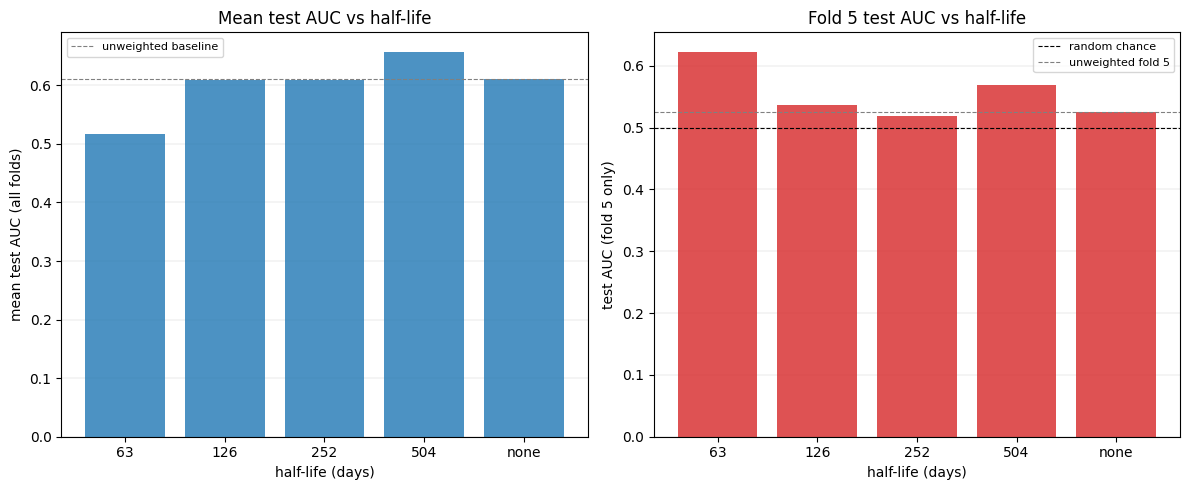

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

hl_labels = [str(hl) if hl else "none" for hl in HALF_LIFE_VALUES]
mean_aucs  = [np.mean([f["auc"] for f in hl_results[hl]]) for hl in HALF_LIFE_VALUES]
fold5_aucs = [next(f["auc"] for f in hl_results[hl] if f["fold"] == 5) for hl in HALF_LIFE_VALUES]

x = range(len(HALF_LIFE_VALUES))

ax1.bar(x, mean_aucs, color="#1f77b4", alpha=0.8)
ax1.axhline(np.mean([f["auc"] for f in best_folds]), color="grey", linestyle="--",
            linewidth=0.8, label="unweighted baseline")
ax1.set_xticks(list(x))
ax1.set_xticklabels(hl_labels)
ax1.set_xlabel("half-life (days)")
ax1.set_ylabel("mean test AUC (all folds)")
ax1.set_title("Mean test AUC vs half-life")
ax1.legend(fontsize=8)
ax1.yaxis.grid(True, linewidth=0.3, color="grey", alpha=0.4)
ax1.set_axisbelow(True)

ax2.bar(x, fold5_aucs, color="#d62728", alpha=0.8)
ax2.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="random chance")
ax2.axhline(next(f["auc"] for f in best_folds if f["fold"] == 5),
            color="grey", linestyle="--", linewidth=0.8, label="unweighted fold 5")
ax2.set_xticks(list(x))
ax2.set_xticklabels(hl_labels)
ax2.set_xlabel("half-life (days)")
ax2.set_ylabel("test AUC (fold 5 only)")
ax2.set_title("Fold 5 test AUC vs half-life")
ax2.legend(fontsize=8)
ax2.yaxis.grid(True, linewidth=0.3, color="grey", alpha=0.4)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [21]:
# Select by mean test AUC. The gap criterion is misleading here because fold 1
# (GFC) inflates the mean gap regardless of half-life.
best_hl = max(HALF_LIFE_VALUES, key=lambda hl: np.mean([f["auc"] for f in hl_results[hl]]))
print(f"best half-life: {best_hl}")

BEST_PARAMS_WEIGHTED = {**BEST_PARAMS, "eval_metric": "logloss", "verbosity": 0}
weighted_folds = hl_results[best_hl]

print(f"\nfinal CV (half-life={best_hl}):")
for f in weighted_folds:
    gap = f["train_auc"] - f["auc"]
    print(
        f"  fold {f['fold']} ({f['test_start']} to {f['test_end']}): "
        f" train={f['train_auc']:.4f}  test={f['auc']:.4f}  gap={gap:.4f}"
    )

base_mean   = np.mean([f["auc"] for f in best_folds])
weight_mean = np.mean([f["auc"] for f in weighted_folds])
base_gap    = np.mean([f["train_auc"] - f["auc"] for f in best_folds])
weight_gap  = np.mean([f["train_auc"] - f["auc"] for f in weighted_folds])
print()
print(f"baseline             AUC: {np.mean(baseline_aucs):.4f}")
print(f"XGBoost (unweighted) AUC: {base_mean:.4f}  gap: {base_gap:.4f}")
print(f"XGBoost (hl={best_hl})   AUC: {weight_mean:.4f}  gap: {weight_gap:.4f}")

best half-life: 504

final CV (half-life=504):
  fold 1 (2008-12-17 to 2012-05-14):  train=0.9999  test=0.4631  gap=0.5369
  fold 2 (2012-05-15 to 2015-10-12):  train=0.9971  test=0.7820  gap=0.2151
  fold 3 (2015-10-13 to 2019-03-11):  train=0.9939  test=0.7928  gap=0.2011
  fold 4 (2019-03-12 to 2022-08-04):  train=0.9785  test=0.6815  gap=0.2970
  fold 5 (2022-08-05 to 2025-12-30):  train=0.8593  test=0.5688  gap=0.2905

baseline             AUC: 0.6502
XGBoost (unweighted) AUC: 0.6102  gap: 0.3873
XGBoost (hl=504)   AUC: 0.6576  gap: 0.3081


### 12. Regularization sweep (random search) + recency weighting

Section 11 showed that hl=504 recency weighting is the primary lever: XGBoost without
weighting (AUC 0.610) underperforms the equal-weight baseline (AUC 0.650), while hl=504
brings it to 0.658. This section tests whether adding regularization on top of hl=504
provides any further lift.

The sweep is identical to before but `_random_sweep_job` now uses `run_xgb_cv_weighted`
with `half_life=504`. The comparison at the end shows all four configurations.

In [22]:
import random
from scipy.stats import uniform

RANDOM_BASE_PARAMS = {
    "n_estimators": best["n_estimators"],
    "learning_rate": best["learning_rate"],
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42,
    "tree_method": "hist",
}

PARAM_DIST = {
    "max_depth": [2, 3],
    "subsample": uniform(0.4, 0.4),       # 0.4 to 0.8
    "colsample_bytree": uniform(0.4, 0.4),
    "reg_alpha": [0.1, 1.0, 5.0, 10.0, 20.0],
    "reg_lambda": [1.0, 5.0, 10.0, 20.0],
}

N_ITER = 50
random.seed(42)
combos = [
    {k: (v.rvs() if hasattr(v, "rvs") else random.choice(v)) for k, v in PARAM_DIST.items()}
    for _ in range(N_ITER)
]


def _random_sweep_job(combo, X, y):
    folds = run_xgb_cv_weighted({**RANDOM_BASE_PARAMS, **combo}, X, y, half_life=504)
    train_auc = np.mean([f["train_auc"] for f in folds])
    test_auc = np.mean([f["auc"] for f in folds])
    gap = train_auc - test_auc
    score = test_auc - abs(gap)
    return {**combo, "mean_train_auc": train_auc, "mean_auc": test_auc, "gap": gap, "score": score}


random_raw = Parallel(n_jobs=N_JOBS)(
    delayed(_random_sweep_job)(c, X_data, y_data) for c in combos
)
random_results = sorted(random_raw, key=lambda r: r["score"], reverse=True)
best_random = random_results[0]
print("random search complete")
print(
    f"best: depth={best_random['max_depth']}  alpha={best_random['reg_alpha']:.1f}"
    f"  lambda={best_random['reg_lambda']:.1f}  sub={best_random['subsample']:.2f}"
    f"  col={best_random['colsample_bytree']:.2f}"
)
print(
    f"      AUC={best_random['mean_auc']:.4f}  gap={best_random['gap']:.4f}"
    f"  score={best_random['score']:.4f}"
)

random search complete
best: depth=2  alpha=1.0  lambda=5.0  sub=0.64  col=0.42
      AUC=0.6702  gap=0.2540  score=0.4162


In [23]:
print(f"{'depth':>5}  {'alpha':>6}  {'lambda':>6}  {'sub':>4}  {'col':>4}"
      f"  {'train_AUC':>9}  {'AUC':>7}  {'gap':>6}  {'score':>7}")
for r in random_results[:15]:
    print(
        f"{r['max_depth']:>5}  {r['reg_alpha']:>6.1f}  {r['reg_lambda']:>6.1f}"
        f"  {r['subsample']:>4.2f}  {r['colsample_bytree']:>4.2f}"
        f"  {r['mean_train_auc']:>9.4f}  {r['mean_auc']:>7.4f}"
        f"  {r['gap']:>6.4f}  {r['score']:>7.4f}"
    )

depth   alpha  lambda   sub   col  train_AUC      AUC     gap    score
    2     1.0     5.0  0.64  0.42     0.9243   0.6702  0.2540   0.4162
    2     0.1     1.0  0.76  0.53     0.9394   0.6718  0.2676   0.4042
    2     5.0     1.0  0.51  0.45     0.9178   0.6589  0.2589   0.3999
    2    10.0     1.0  0.80  0.47     0.9144   0.6527  0.2617   0.3910
    2     0.1    10.0  0.51  0.42     0.9183   0.6540  0.2642   0.3898
    2     1.0     5.0  0.44  0.54     0.9222   0.6547  0.2675   0.3872
    2    20.0    20.0  0.45  0.46     0.8906   0.6375  0.2531   0.3844
    2     5.0     5.0  0.78  0.64     0.9201   0.6519  0.2682   0.3837
    2     1.0     1.0  0.52  0.74     0.9344   0.6577  0.2768   0.3809
    2     0.1     1.0  0.65  0.61     0.9395   0.6597  0.2798   0.3798
    2     1.0    10.0  0.57  0.59     0.9180   0.6476  0.2704   0.3772
    2     5.0     5.0  0.41  0.72     0.9116   0.6430  0.2686   0.3744
    2     5.0     1.0  0.70  0.61     0.9218   0.6480  0.2737   0.3743
    2 

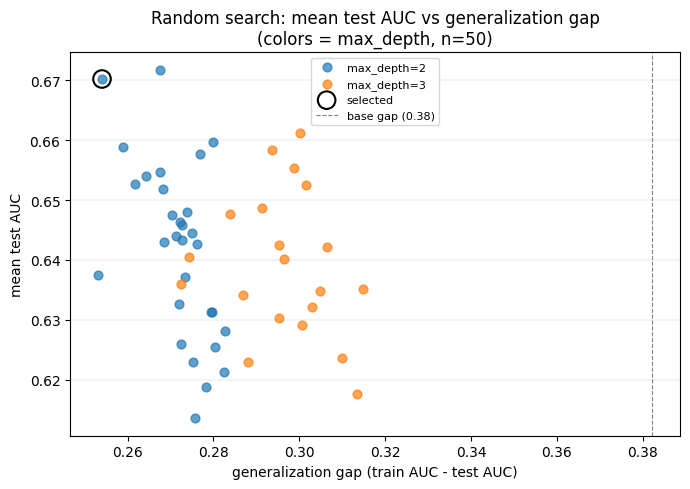

In [24]:
depths = sorted(set(r["max_depth"] for r in random_results))
colors_depth = {d: c for d, c in zip(depths, ["#1f77b4", "#ff7f0e"])}

gaps_r = [r["gap"] for r in random_results]
test_aucs_r = [r["mean_auc"] for r in random_results]
best_r_idx = random_results.index(best_random)
orig_gap = best["mean_train_auc"] - best["mean_auc"]

fig, ax = plt.subplots(figsize=(7, 5))

for d in depths:
    idx = [i for i, r in enumerate(random_results) if r["max_depth"] == d]
    ax.scatter(
        [gaps_r[i] for i in idx],
        [test_aucs_r[i] for i in idx],
        color=colors_depth[d],
        label=f"max_depth={d}",
        s=40,
        alpha=0.7,
        zorder=3,
    )

ax.scatter(
    gaps_r[best_r_idx],
    test_aucs_r[best_r_idx],
    s=160,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    zorder=4,
    label="selected",
)
ax.axvline(orig_gap, color="grey", linestyle="--", linewidth=0.8, label=f"base gap ({orig_gap:.2f})")

ax.set_xlabel("generalization gap (train AUC - test AUC)")
ax.set_ylabel("mean test AUC")
ax.set_title("Random search: mean test AUC vs generalization gap\n(colors = max_depth, n=50)")
ax.legend(fontsize=8)
ax.yaxis.grid(True, linewidth=0.3, color="grey", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [25]:
BEST_PARAMS_RANDOM = {
    **RANDOM_BASE_PARAMS,
    "max_depth": best_random["max_depth"],
    "subsample": best_random["subsample"],
    "colsample_bytree": best_random["colsample_bytree"],
    "reg_alpha": best_random["reg_alpha"],
    "reg_lambda": best_random["reg_lambda"],
}

reg_folds = run_xgb_cv_weighted(BEST_PARAMS_RANDOM, X_data, y_data, half_life=504)

print("final CV (hl=504 + regularization):")
for f in reg_folds:
    print(
        f"  fold {f['fold']} ({f['test_start']} to {f['test_end']}): "
        f" train={f['train_auc']:.4f}  test={f['auc']:.4f}  Brier={f['brier']:.4f}"
    )

unweighted_auc  = np.mean([f["auc"] for f in best_folds])
hl504_auc       = np.mean([f["auc"] for f in hl_results[504]])
reg_auc         = np.mean([f["auc"] for f in reg_folds])
unweighted_gap  = np.mean([f["train_auc"] - f["auc"] for f in best_folds])
hl504_gap       = np.mean([f["train_auc"] - f["auc"] for f in hl_results[504]])
reg_gap         = np.mean([f["train_auc"] - f["auc"] for f in reg_folds])

print()
print(f"baseline                   AUC: {np.mean(baseline_aucs):.4f}")
print(f"XGBoost (unweighted)       AUC: {unweighted_auc:.4f}  gap: {unweighted_gap:.4f}")
print(f"XGBoost (hl=504)           AUC: {hl504_auc:.4f}  gap: {hl504_gap:.4f}")
print(f"XGBoost (hl=504 + reg)     AUC: {reg_auc:.4f}  gap: {reg_gap:.4f}")


final CV (hl=504 + regularization):
  fold 1 (2008-12-17 to 2012-05-14):  train=0.9978  test=0.4654  Brier=0.2902
  fold 2 (2012-05-15 to 2015-10-12):  train=0.9876  test=0.7730  Brier=0.1643
  fold 3 (2015-10-13 to 2019-03-11):  train=0.9743  test=0.7797  Brier=0.1283
  fold 4 (2019-03-12 to 2022-08-04):  train=0.8938  test=0.7424  Brier=0.1731
  fold 5 (2022-08-05 to 2025-12-30):  train=0.7751  test=0.5925  Brier=0.1688

baseline                   AUC: 0.6502
XGBoost (unweighted)       AUC: 0.6102  gap: 0.3873
XGBoost (hl=504)           AUC: 0.6576  gap: 0.3081
XGBoost (hl=504 + reg)     AUC: 0.6706  gap: 0.2551
